In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams.update({'font.size': 10})

In [2]:
mydir = '../processed_netcdf/'

In [3]:
def is_feb(month):
    return month==2

def is_sep(month):
    return month==9

In [4]:
moddir = '../processed_netcdf/CMIP6_sic_1979-2018/'
allfiles = sorted([f for f in os.listdir(moddir) if 'siconc_SImon' in f])
modnames = [f.split('_')[2] for f in allfiles]

incnames = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_r1_updated.nc').name.values
incnames  = [f.strip().split('_')[0] for f in incnames]
modnames = [f for f in modnames if f in incnames]


obsdir='../processed_netcdf/OBS_sic_1979-2018/'
obsnames = ['Bootstrap','NASA-Team','osisaf']
modnames = sorted(list(set(modnames)))
nobs = len(obsnames)
names = obsnames+ modnames
print(names)
nmod = len(names)
print(len(names))

trenddir = '../processed_netcdf/CMIP6_sic_1979-2018/trends/'
trendnames = [f.split('_')[2] for f in os.listdir(trenddir)]
trendnames

['Bootstrap', 'NASA-Team', 'osisaf', 'ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'UKESM1-0-LL']
32


['GFDL-ESM4',
 'ACCESS-CM2',
 'osisaf',
 'NorESM2-LM',
 'CESM2-WACCM',
 'CNRM-CM6-1',
 'FIO-ESM-2-0',
 'AWI-CM-1-1-MR',
 'CAMS-CSM1-0',
 'UKESM1-0-LL',
 'Bootstrap',
 'FGOALS-f3-L',
 'INM-CM5-0',
 'CESM2',
 'ACCESS-ESM1-5',
 'CNRM-ESM2-1',
 'BCC-CSM2-MR',
 'MRI-ESM2-0',
 'NASA-Team',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MIROC6',
 'CanESM5',
 'MIROC-ES2L',
 'HadGEM3-GC31-LL',
 'NESM3',
 'GFDL-CM4',
 'CNRM-CM6-1-HR',
 'IPSL-CM6A-LR',
 'EC-Earth3',
 'INM-CM4-8',
 'EC-Earth3-Veg']

In [5]:
maps = [Basemap(projection='npstere', boundinglat=55, lon_0 = 0),Basemap(projection='spstere', boundinglat=-55, lon_0 = 180)]

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [6]:
for n,name in enumerate(names):
     
    if name not in trendnames:

        print(name)
        if n<nobs:
            mydir = obsdir
        else:
            mydir = moddir

        ensfiles = [f for f in os.listdir(mydir) if name+'_' in f][0]

        ds = xr.open_dataset(mydir+ensfiles, chunks={'time': 12})
        if 'siconc' not in ds:
            if 'sic' in ds:
                ds = ds.rename({'sic':'siconc'})
            elif 'seaice' in ds:
                ds = ds.rename({'seaice':'siconc'})
            ds.siconc.values = 100.*ds.siconc.values

        ds.siconc.values = ds.siconc.where(ds.siconc<=100.)
        print(name,np.nanmax(ds.siconc.values))
        ds = myF.lat_renamer(ds)
        
        
        monds = []
        for ct,month in enumerate([1,8]):
            if month==1:
                mydata = ds.sel(time=is_feb(ds['time.month'])).siconc
            elif month==8:
                mydata = ds.sel(time=is_sep(ds['time.month'])).siconc
                
            climsic = mydata.mean(dim='time').to_dataset(name='siconc')
            
            climsic['latitude'] = ds.isel(time=0).latitude
            climsic = climsic.set_coords('latitude')
            climsic['longitude'] = ds.isel(time=0).longitude
            climsic = climsic.set_coords('longitude')
            climsic = climsic.squeeze()
            print(climsic)
            

            trend_mod, _, rval, pval, std_err = myF.linregress(np.arange(40),mydata,dim='time')

            trend_mod = trend_mod.to_dataset(name='siconc_trend')
            pval = pval.to_dataset(name='siconc_pval')
            rval = rval.to_dataset(name='siconc_rval')
            std_err = std_err.to_dataset(name='siconc_stderr')

            
            mergeds = xr.merge([climsic,trend_mod,pval,std_err])
            mergeds.attrs = ds.attrs
            mergeds['month'] = month+1

            monds.append(mergeds)
        outds = xr.concat(monds,dim='month')
        outds['name'] = name 
        print(outds)

        outds.to_netcdf('../processed_netcdf/CMIP6_sic_1979-2018/trends/'+ensfiles[:-3]+'_trend.nc')

Bootstrap
['siconc_OBS_Bootstrap_monthly_sh_1979-2018_trend.nc']
NASA-Team
['siconc_OBS_NASA-Team_monthly_sh_1979-2018_trend.nc']
osisaf
['siconc_OBS_osisaf_monthly_sh_1979-2018_trend.nc']
ACCESS-CM2
['siconc_SImon_ACCESS-CM2_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
ACCESS-ESM1-5
['siconc_SImon_ACCESS-ESM1-5_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
AWI-CM-1-1-MR
['siconc_SImon_AWI-CM-1-1-MR_hist+ssp245_r1i1p1f1_gn_197901-2018_trend.nc']
BCC-CSM2-MR
['siconc_SImon_BCC-CSM2-MR_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CAMS-CSM1-0
['siconc_SImon_CAMS-CSM1-0_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CESM2
['siconc_SImon_CESM2_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CESM2-WACCM
['siconc_SImon_CESM2-WACCM_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CNRM-CM6-1
['siconc_SImon_CNRM-CM6-1_hist+ssp245_r1i1p1f2_gn_197901-201812_trend.nc']
CNRM-CM6-1-HR
['siconc_SImon_CNRM-CM6-1-HR_hist+ssp245_r1i1p1f2_gn_197901-201812_trend.nc']
CNRM-ESM2-1
['siconc_SImo

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


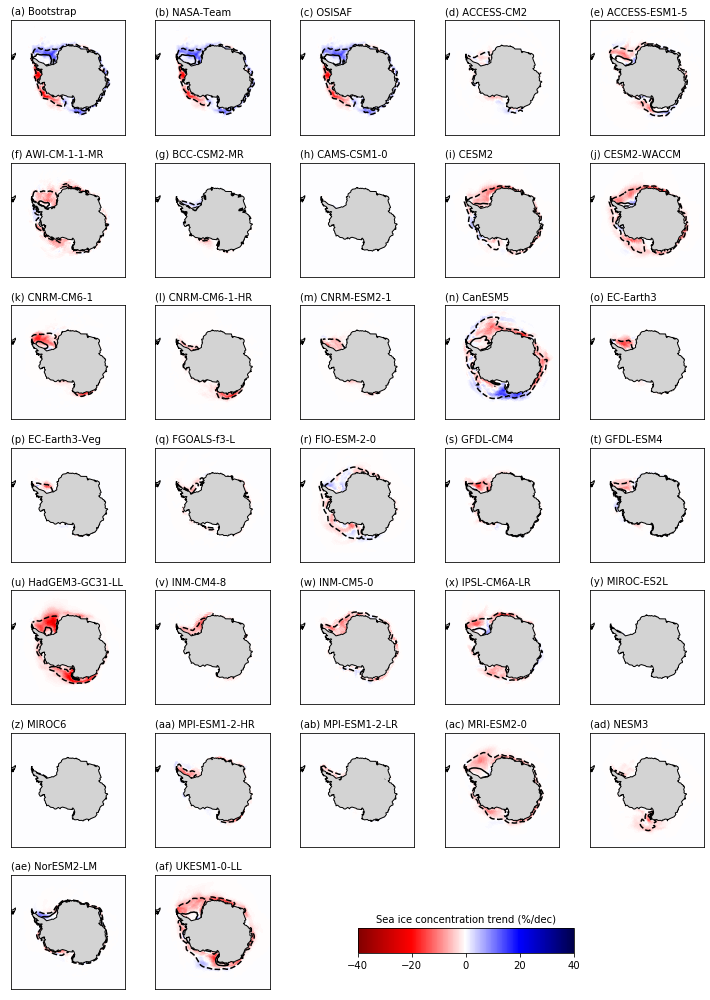

Bootstrap
['siconc_OBS_Bootstrap_monthly_sh_1979-2018_trend.nc']
NASA-Team
['siconc_OBS_NASA-Team_monthly_sh_1979-2018_trend.nc']
osisaf
['siconc_OBS_osisaf_monthly_sh_1979-2018_trend.nc']
ACCESS-CM2
['siconc_SImon_ACCESS-CM2_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
ACCESS-ESM1-5
['siconc_SImon_ACCESS-ESM1-5_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
AWI-CM-1-1-MR
['siconc_SImon_AWI-CM-1-1-MR_hist+ssp245_r1i1p1f1_gn_197901-2018_trend.nc']
BCC-CSM2-MR
['siconc_SImon_BCC-CSM2-MR_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CAMS-CSM1-0
['siconc_SImon_CAMS-CSM1-0_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CESM2
['siconc_SImon_CESM2_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CESM2-WACCM
['siconc_SImon_CESM2-WACCM_hist+ssp245_r1i1p1f1_gn_197901-201812_trend.nc']
CNRM-CM6-1
['siconc_SImon_CNRM-CM6-1_hist+ssp245_r1i1p1f2_gn_197901-201812_trend.nc']
CNRM-CM6-1-HR
['siconc_SImon_CNRM-CM6-1-HR_hist+ssp245_r1i1p1f2_gn_197901-201812_trend.nc']
CNRM-ESM2-1
['siconc_SImo

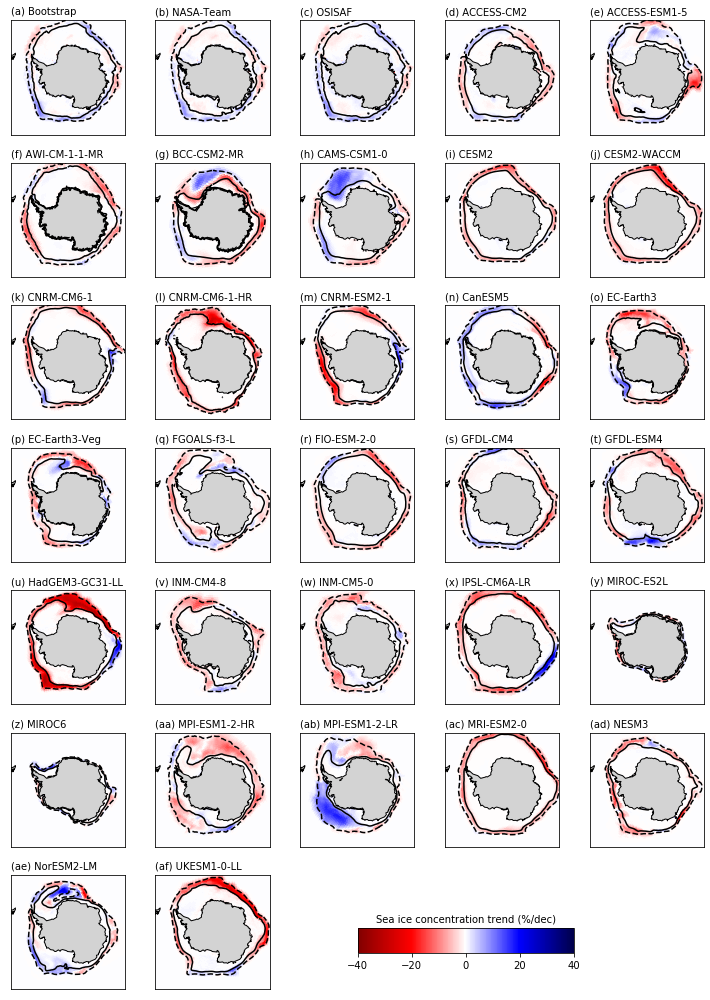

In [33]:
h=1
labels = names.copy()
labels[2] = 'OSISAF'
for ct,month in enumerate([1,8]):
    fig = plt.figure(figsize=(10,14))
    plt.rcParams.update({'font.size': 10})


    for n,name in enumerate(names):
        print(name)
        myfile = [f for f in os.listdir(trenddir) if name+'_' in f]
        print(myfile)
        myfile = myfile[0]
        ds = xr.open_dataset(trenddir+myfile)
        ax = plt.subplot(7,5,n+1)
        ax.set_title(myF.alphabet[n]+' '+labels[n],fontsize=10,loc='left')
        m = maps[h]
        
        lat = ds.latitude.values
        lon = ds.longitude.values
        
        if lat.shape != lon.shape:
            lat = np.swapaxes(np.tile(lat,(len(lon),1)),0,1)
            lon = np.tile(lon,(len(lat),1))
       
        x, y = m(lon,lat)
        
        #trends in pcolor
        mydata = ds.siconc_trend[ct,:,:]
        mydata = ma.masked_where(lat>0,mydata)
        mydata = ma.masked_invalid(mydata)
        #print(np.max(mydata*10.),np.min(mydata*10.))
        CS2 = m.pcolor(x,y,10.*mydata,cmap = plt.cm.seismic_r,vmin=-40.,vmax=40.)       #4 to -4
       
        
        #pdata = 100.*(1-ds.siconc_pval[ct,:,:].values)
        
        #pdata = ma.masked_where(np.ma.abs(mydata)<0.2,pdata)  
        #pdata = ma.masked_where(pdata<95.,pdata)
        #pdata = ma.masked_invalid(pdata)
        #print(np.nanmax(pdata))
        #CS0 = m.contour(x, y, pdata,  level=[95], colors=['orange'],linewidth=.5)
        #CS0 = m.contourf(x, y, pdata,  hatch='//',cmap = plt.cm.Greys, alpha=0.5)
        
        mydata = ds.siconc[ct,:,:].values
        mydata = ma.masked_where(lat>0,mydata)
        mydata = ma.masked_invalid(mydata)
        CS1 = m.contour(x,y,mydata,levels=[15.,80.],linestyles=['--','-'],colors=['black','black'])
      
        
        m.drawcoastlines(color='black')
        m.fillcontinents(color='lightgrey')
        
       
    cbar_ax = fig.add_axes([0.5, 0.05, 0.3, 0.025]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS2, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title('Sea ice concentration trend (%/dec)',fontsize=10)
    plt.tight_layout()
    fig.savefig('figS'+str((ct+7)),bbox_inches='tight',dpi=600)
    plt.show()
    plt.close()


In [ ]:
        pdata = 100.*(1-ds.siconc_pval[ct,:,:].values)
        pdata = ma.masked_where(lat>0,pdata)
        
        pdata = ma.masked_where(np.ma.abs(mydata)>0.05,pdata)
        pdata = ma.masked_invalid(pdata)
        #CS0 = m.contour(x,y,pdata,levels=[95.],linestyles=['-'],colors=['gold'])
        CS0 = m.pcolor(x, y, pdata, hatch='/', alpha=0.)
      
         #mean sea ice contours
        mydata = ds.siconc[ct,:,:].values
        #mydata = ma.masked_where(lat>0,mydata)
        #mydata = ma.masked_invalid(mydata)
        CS1 = m.contour(x,y,mydata,levels=[15.,80.],linestyles=['--','-'],colors=['black','black'])
      